In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
attack_df = pd.read_csv("../data/clean_data/modeling_data.csv")
attack_df = attack_df[attack_df["activity"] != "adrift"]
# attack_df.drop(["country", "time", "month", "hemisphere", "species"], axis=1, inplace=True)
print(f"Num attacks: {len(attack_df)}")

attack_df.head()

Num attacks: 3358


,country,state,activity,fatal,time,species,month,hemisphere,season
0,usa,florida,swimming,N,morning,NaN,6.0,northern,summer
1,australia,new south wales,swimming,N,morning,great white,6.0,southern,winter
2,usa,florida,swimming,N,morning,bull,6.0,northern,summer
3,australia,western australia,dive fishing,Y,morning,great white,6.0,southern,winter
4,australia,new south wales,surfing/bodyboarding,N,evening,bull,5.0,southern,fall


In [25]:
# function to plate fatality rates by different attributes
def fatality_rate_plots(fatal_counts_df, prop_fatal, attribute_name: str, max_x=1400, legend_pos="lower right", title="NULL"):

    fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
    axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.5)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(title, fontsize=16)

    # plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


def prep_for_viz(df, var_name):

    total_attacks = len(df)

    nonfatal_df = df[df["fatal"] == "N"]
    fatal_df = df[df["fatal"] == "Y"]

    prop_fatal = len(fatal_df) / total_attacks

    counts1 = fatal_df.groupby(var_name).size().to_frame(name="fatal_count").reset_index()
    counts2 = nonfatal_df.groupby(var_name).size().to_frame(name="nonfatal_count").reset_index()

    counts = counts2.merge(counts1, on=var_name, how="left").fillna(0)
    counts["total_count"] = counts["fatal_count"] + counts["nonfatal_count"]
    counts["fatality_rate"] = counts["fatal_count"] / counts["total_count"]

    # counts.sort_values("total_count", ascending=True, inplace=True)

    return counts, prop_fatal

## 

0.15604526503871352


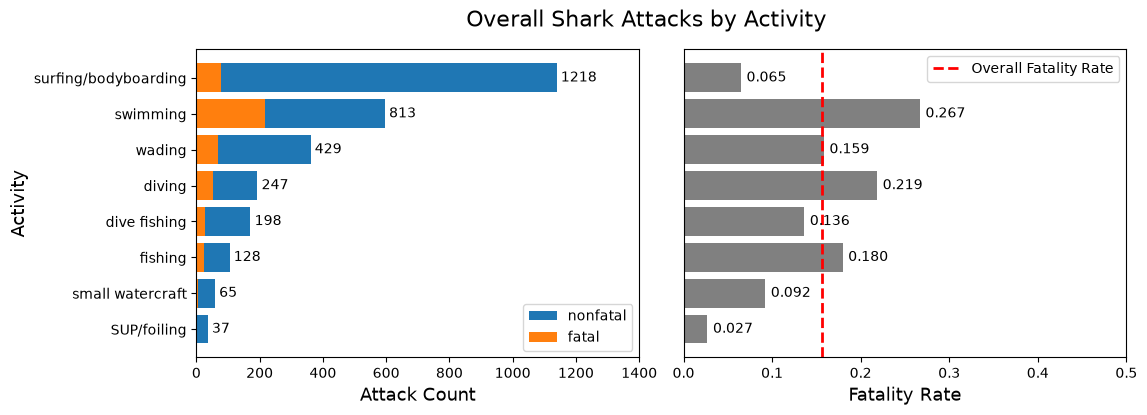

In [26]:
all_attacks, prop_fatal = prep_for_viz(attack_df, "activity")
print(prop_fatal)
fatality_rate_plots(all_attacks, attribute_name="activity", prop_fatal=prop_fatal, title="Overall Shark Attacks by Activity")

               activity  nonfatal_count  fatal_count  total_count  \
0           SUP/foiling               4          0.0          4.0   
3               fishing              11          3.0         14.0   
1          dive fishing              16          1.0         17.0   
4      small watercraft              17          0.0         17.0   
2                diving              15          5.0         20.0   
7                wading              25         23.0         48.0   
6              swimming              41         39.0         80.0   
5  surfing/bodyboarding             131         13.0        144.0   

   fatality_rate  
0       0.000000  
3       0.214286  
1       0.058824  
4       0.000000  
2       0.250000  
7       0.479167  
6       0.487500  
5       0.090278  


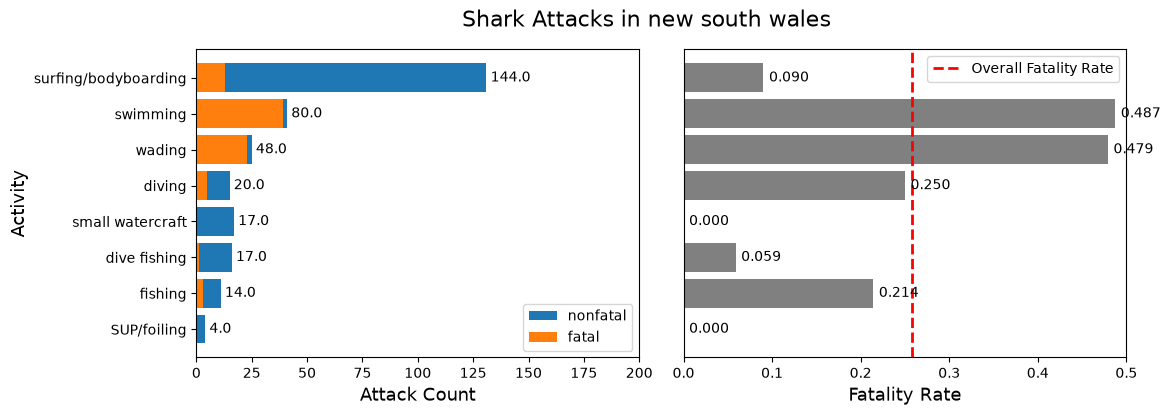

In [18]:
nsw_attacks = attack_df[attack_df["state"] == "new south wales"]
other_attacks = attack_df[attack_df["state"] != "new south wales"]

nsw_attacks, nsw_prop = prep_for_viz(nsw_attacks, "activity")
print(nsw_attacks)
fatality_rate_plots(nsw_attacks, attribute_name="activity", prop_fatal=nsw_prop, title="Shark Attacks in new south wales", max_x = 200)

nsw prop: 0.25806451612903225
other prop: 0.14333556597454788


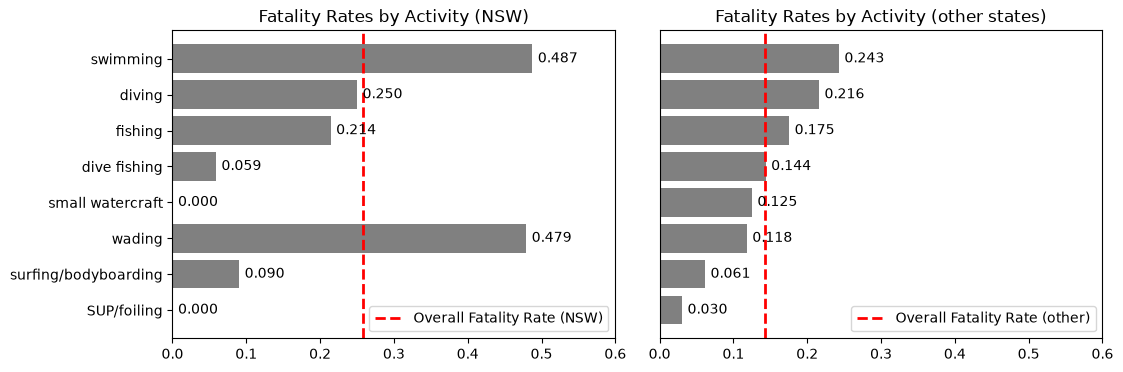

In [46]:
nsw_attacks = attack_df[attack_df["state"] == "new south wales"]
other_attacks = attack_df[attack_df["state"] != "new south wales"]

nsw_attacks, nsw_prop = prep_for_viz(nsw_attacks, "activity")
other_attacks, other_prop = prep_for_viz(other_attacks, "activity")

print(f"nsw prop: {nsw_prop}\nother prop: {other_prop}")

merged = pd.merge(nsw_attacks, other_attacks, on="activity", suffixes=("_nsw", "_other"))
merged.sort_values("fatality_rate_other", ascending=True, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

# bar chart for death rates
axes[0].barh(
    merged["activity"],
    merged["fatality_rate_nsw"],
    color="gray"
)
axes[0].axvline(x=nsw_prop, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate (NSW)')
axes[0].bar_label(axes[0].containers[0], fmt='%.3f', padding=4)
# axes[0].set_yticks([])
axes[0].set_xlim(0, 0.6)
axes[0].set_title("Fatality Rates by Activity (NSW)")
axes[0].legend()


axes[1].barh(
    merged["activity"],
    merged["fatality_rate_other"],
    color="gray"
)
axes[1].axvline(x=other_prop, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate (other)')
axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
axes[1].set_yticks([])
axes[1].set_xlim(0, 0.6)
axes[1].set_title("Fatality Rates by Activity (other states)")
axes[1].legend()

plt.savefig(f"../figures/nsw_vs_other.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
merged

,activity,nonfatal_count_nsw,fatal_count_nsw,total_count_nsw,fatality_rate_nsw,nonfatal_count_other,fatal_count_other,total_count_other,fatality_rate_other
0,SUP/foiling,4,0.0,4.0,0.000000,32,1,33,0.030303
7,surfing/bodyboarding,131,13.0,144.0,0.090278,1008,66,1074,0.061453
5,wading,25,23.0,48.0,0.479167,336,45,381,0.118110
3,small watercraft,17,0.0,17.0,0.000000,42,6,48,0.125000
2,dive fishing,16,1.0,17.0,0.058824,155,26,181,0.143646
1,fishing,11,3.0,14.0,0.214286,94,20,114,0.175439
4,diving,15,5.0,20.0,0.250000,178,49,227,0.215859
6,swimming,41,39.0,80.0,0.487500,555,178,733,0.242838
